## Initial settings



In [1]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import pickle
import warnings
warnings.filterwarnings("ignore")
import matplotlib
matplotlib.use('Qt5Agg')
import matplotlib.pyplot as plt
from matplotlib import gridspec
plt.ion()
import pandas as pd
from datetime import datetime
import pytz
from coastsat import SDS_download, SDS_preprocess, SDS_shoreline, SDS_tools, SDS_transects

Authenticate GEE with your project name. Replace `project_name` with your own. If you don't know it, open a terminal and run `gcloud config get-value project`.

In [2]:
# authenticate GEE with project name (YOU NEED TO INPUT YOUR OWN PROJECT NAME)
project_name = 'ee-nguyenphucvpag'
SDS_download.authenticate_and_initialize(project_name)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_9oS0DRcPvElRMNw?source=python


GEE initialized (existing token).


## Retrieval of the images from GEE

In [7]:
# region of interest (longitude, latitude)
polygon = [[[151.2957545, -33.7012561],
            [151.297557, -33.7388075],
            [151.312234, -33.7390216],
            [151.311204, -33.701399],
            [151.2957545, -33.7012561]]]
polygon = SDS_tools.smallest_rectangle(polygon)
# date range
dates = ['2005-01-01', '2008-12-31']
# satellite missions ['L5','L7','L8','L9','S2']
sat_list = ['L5']
# name of the site
sitename = 'zhao'
filepath = os.path.join(os.getcwd(), 'data')
inputs = {
    'polygon': polygon,
    'dates': dates,
    'sat_list': sat_list,
    'sitename': sitename,
    'filepath': filepath
}

# ============================================================
# Super-resolution method
# ============================================================
inputs['sr_method'] = 'zhao'

# Zhao parameters for L5
inputs['zhao_params'] = {
    'L5': {
        'tau': 0.1,
        'kernel_size': 9,
        'kernel_variance': 3.0,
        'device': None
    }
}

SDS_download.check_images_available(inputs);

Number of images available between 2005-01-01 and 2008-12-31:
- In Landsat Tier 1 & Sentinel-2 Level-1C:
     L5: 61 images
  Total to download: 61 images
- In Landsat Tier 2 (not suitable for time-series analysis):
     L5: 4 images
  Total Tier 2: 4 images


In [8]:
print(filepath)

C:\Users\ADMIN\Downloads\CoastSat-SuperResolution-new\CoastSat-SuperResolution-main\data


In [9]:
# option to skip L7 images affected by the Scan-Line-Correction error after 31st May 2003
inputs['skip_L7_SLC'] = True

In [10]:
metadata = SDS_download.retrieve_images(inputs)

Number of images available between 2005-01-01 and 2008-12-31:
- In Landsat Tier 1 & Sentinel-2 Level-1C:
     L5: 61 images
  Total to download: 61 images
- In Landsat Tier 2 (not suitable for time-series analysis):
     L5: 4 images
  Total Tier 2: 4 images

L5: 61 images

Zhao Algorithm 1 applied
  Satellite: L5
  Device: cpu
  Tau: 0.1
  Input shape: (5, 141, 54)
  Output shape: (5, 282, 108)
  Input range: [0.004151, 0.504258]
  Output range: [-0.034264, 0.559415]
  Zhao forward MSE: 2.08903279e-04
  Bicubic forward MSE: 2.96355429e-04
1%
Zhao Algorithm 1 applied
  Satellite: L5
  Device: cpu
  Tau: 0.1
  Input shape: (5, 141, 54)
  Output shape: (5, 282, 108)
  Input range: [0.004314, 0.506211]
  Output range: [-0.021511, 0.580008]
  Zhao forward MSE: 2.17832014e-04
  Bicubic forward MSE: 3.05665220e-04
3%
Zhao Algorithm 1 applied
  Satellite: L5
  Device: cpu
  Tau: 0.1
  Input shape: (5, 141, 54)
  Output shape: (5, 282, 108)
  Input range: [0.103368, 0.779486]
  Output range: [

**If you have already retrieved the images**, just load the metadata file by only running the section below

In [11]:
metadata = SDS_download.get_metadata(inputs)

In [12]:
print(metadata.keys())
print(len(metadata["L5"]["filenames"]))
print(len(metadata["L7"]["filenames"]))
print(len(metadata["L8"]["filenames"]))
print(len(metadata["L9"]["filenames"]))
print(len(metadata["S2"]["filenames"]))


dict_keys(['L5'])
61


KeyError: 'L7'

## Shoreline extraction


In [13]:
settings = {
    # general parameters:
    'cloud_thresh': 0.5,        # threshold on maximum cloud cover
    'dist_clouds': 300,         # ditance around clouds where shoreline can't be mapped
    'output_epsg': 28356,       # epsg code of spatial reference system desired for the output
    # quality control:
    'check_detection': True,    # if True, shows each shoreline detection to the user for validation
    'adjust_detection': False,  # if True, allows user to adjust the postion of each shoreline by changing the threhold
    'save_figure': True,        # if True, saves a figure showing the mapped shoreline for each image
    # [ONLY FOR ADVANCED USERS] shoreline detection parameters:
    'min_beach_area': 1000,     # minimum area (in metres^2) for an object to be labelled as a beach
    'min_length_sl': 500,       # minimum length (in metres) of shoreline perimeter to be valid
    'cloud_mask_issue': False,  # switch this parameter to True if sand pixels are masked (in black) on many images  
    'sand_color': 'default',    # 'default', 'latest', 'dark' (for grey/black sand beaches) or 'bright' (for white sand beaches)
    'pan_off': False,           # True to switch pansharpening off for Landsat 7/8/9 imagery
    's2cloudless_prob': 60,     # probability threshold to identify cloudy pixels in the s2cloudless mask
    
    # add the inputs defined previously
    'inputs': inputs,
}

### [OPTIONAL] Save RGB images  


In [14]:
SDS_preprocess.save_jpg(metadata, settings, use_matplotlib=True)

Saving images as jpg:
L5: 61 images
100%
Satellite images saved as .jpg in C:\Users\ADMIN\Downloads\CoastSat-SuperResolution-new\CoastSat-SuperResolution-main\data\zhao\jpg_files\preprocessed


### Digitize a reference shoreline 

In [15]:
%matplotlib qt
settings['reference_shoreline'] = SDS_preprocess.get_reference_sl(metadata, settings)
settings['max_dist_ref'] = 100 # max distance (in meters) allowed from the reference shoreline

Reference shoreline has been saved in C:\Users\ADMIN\Downloads\CoastSat-SuperResolution-new\CoastSat-SuperResolution-main\data\zhao


### Batch shoreline detection

In [16]:
# to skip manually checking each image, uncomment below
settings['check_detection'] =False

In [17]:
%matplotlib qt
output = SDS_shoreline.extract_shorelines(metadata, settings)

Mapping shorelines:
L5:   100%


Then remove duplicates and images with inaccurate georeferencing (threhsold at 10m)

In [18]:
output = SDS_tools.remove_duplicates(output) # removes duplicates (images taken on the same date by the same satellite)
output = SDS_tools.remove_inaccurate_georef(output, 10) # remove inaccurate georeferencing (set threshold to 10 m)

0 duplicates
0 bad georef


Simple plot of the mapped shorelines. The coordinates are stored in the output dictionnary together with the exact dates in UTC time, the georeferencing accuracy and the cloud cover.

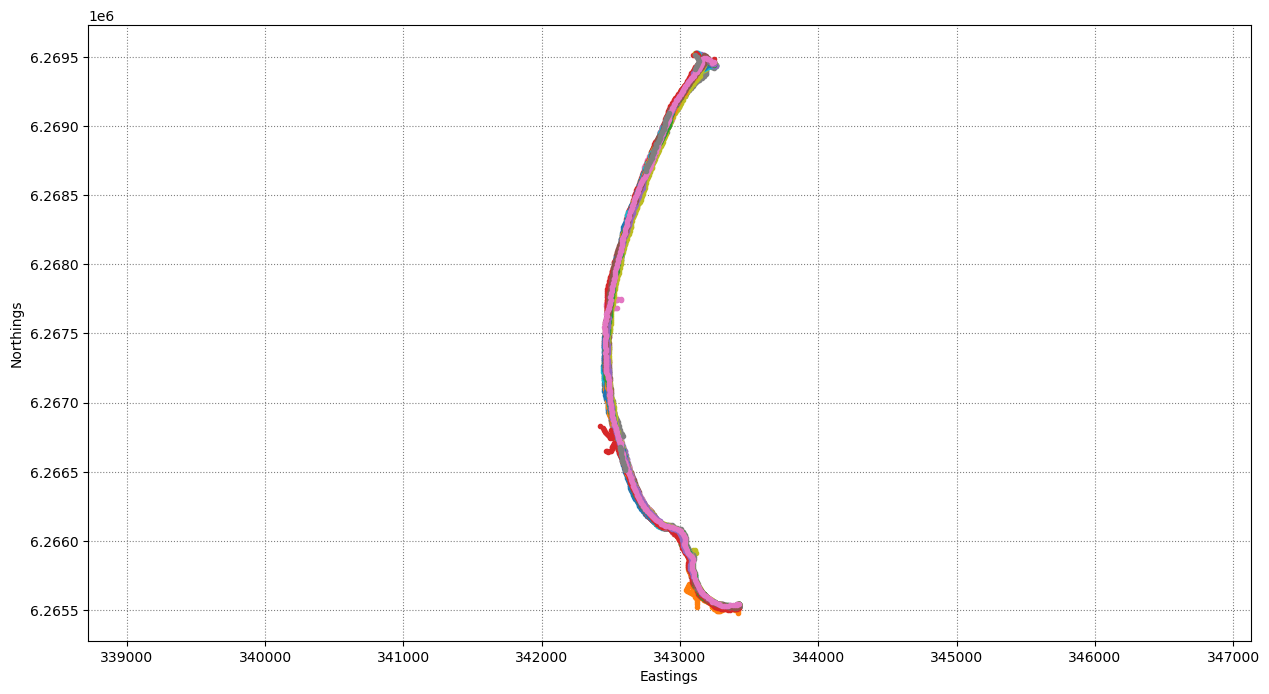

In [19]:
%matplotlib inline
fig = plt.figure(figsize=[15,8])
plt.axis('equal')
plt.xlabel('Eastings')
plt.ylabel('Northings')
plt.grid(linestyle=':', color='0.5')
for i in range(len(output['shorelines'])):
    sl = output['shorelines'][i]
    date = output['dates'][i]
    plt.plot(sl[:,0], sl[:,1], '.', label=date.strftime('%d-%m-%Y'))
# plt.legend();

## Shoreline analysis

In [20]:
filepath = os.path.join(inputs['filepath'], sitename)
with open(os.path.join(filepath, sitename + '_output' + '.pkl'), 'rb') as f:
    output = pickle.load(f)
# remove duplicates (images taken on the same date by the same satellite)
output = SDS_tools.remove_duplicates(output)
# remove inaccurate georeferencing (set threshold to 10 m)
output = SDS_tools.remove_inaccurate_georef(output, 10)

0 duplicates
0 bad georef


Add the transects

In [21]:
transects = dict([])
transects['NA1'] = np.array([[ 342880, 6269180 ], [ 343144, 6269037 ]])
transects['NA2'] = np.array([[ 342733, 6268783 ], [ 343008, 6268664 ]])
transects['NA3'] = np.array([[ 342451, 6267913 ], [ 342746, 6267859 ]])
transects['NA4'] = np.array([[ 342460, 6267042 ], [ 342759, 6267075 ]])
transects['NA5'] = np.array([[ 342675, 6266241 ], [ 342936, 6266388 ]])

Plot the location of the transects

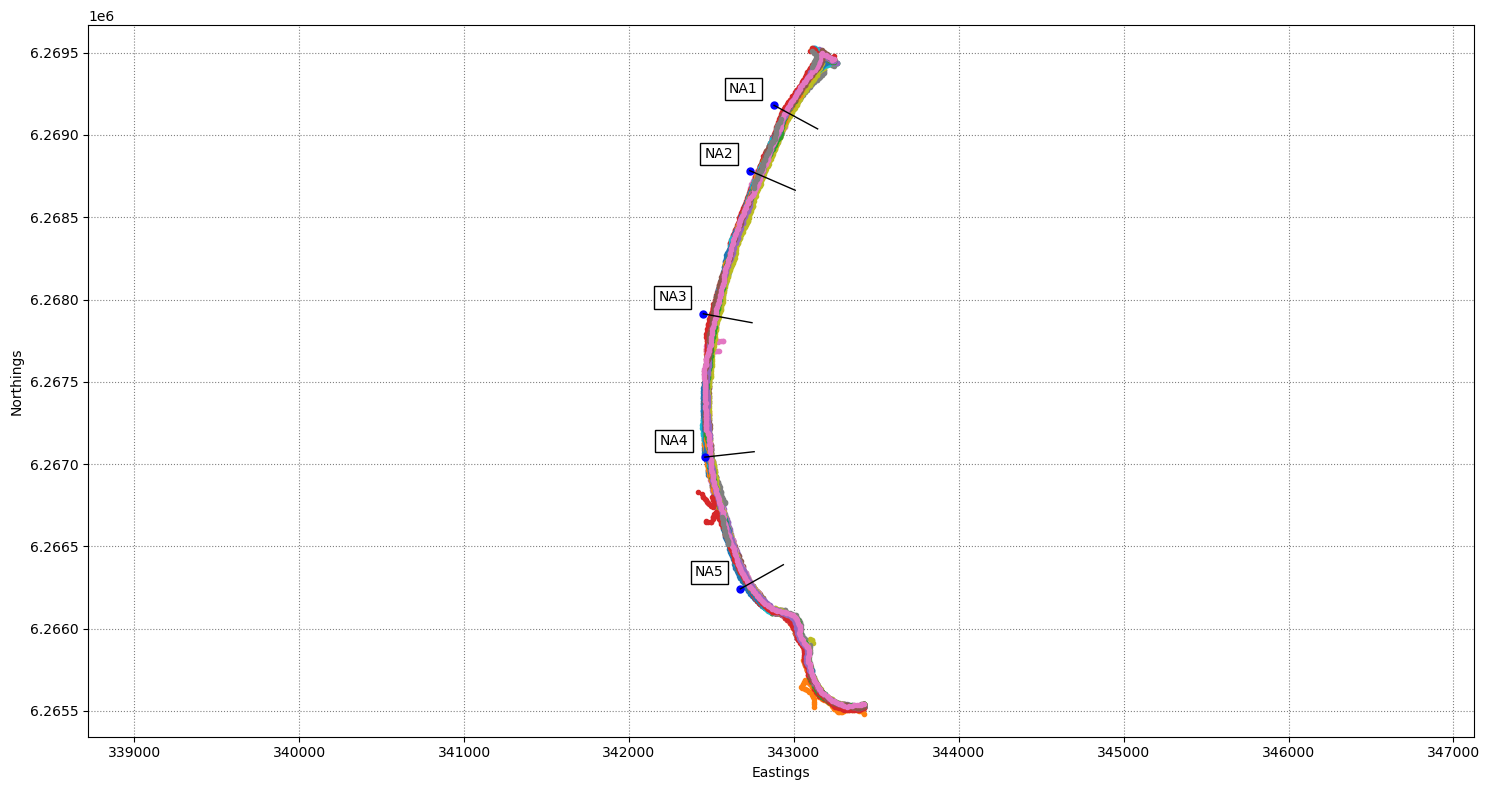

In [22]:
fig = plt.figure(figsize=[15,8], tight_layout=True)
plt.axis('equal')
plt.xlabel('Eastings')
plt.ylabel('Northings')
plt.grid(linestyle=':', color='0.5')
for i in range(len(output['shorelines'])):
    sl = output['shorelines'][i]
    date = output['dates'][i]
    plt.plot(sl[:,0], sl[:,1], '.', label=date.strftime('%d-%m-%Y'))
for i,key in enumerate(list(transects.keys())):
    plt.plot(transects[key][0,0],transects[key][0,1], 'bo', ms=5)
    plt.plot(transects[key][:,0],transects[key][:,1],'k-',lw=1)
    plt.text(transects[key][0,0]-100, transects[key][0,1]+100, key,
                va='center', ha='right', bbox=dict(boxstyle="square", ec='k',fc='w'))
fig.savefig(os.path.join(filepath,'%s_mapped_shorelines.jpg'%sitename),dpi=200)

Compute cross distance

In [23]:
settings_transects = { # parameters for computing intersections
                      'along_dist':          25,        # along-shore distance to use for computing the intersection
                      'min_points':          3,         # minimum number of shoreline points to calculate an intersection
                      'max_std':             15,        # max std for points around transect
                      'max_range':           30,        # max range for points around transect
                      'min_chainage':        -100,      # largest negative value along transect (landwards of transect origin)
                      'multiple_inter':      'auto',    # mode for removing outliers ('auto', 'nan', 'max')
                      'auto_prc':            0.1,       # percentage of the time that multiple intersects are present to use the max
                     }
cross_distance = SDS_transects.compute_intersection_QC(output, transects, settings_transects) 

Plot the time-series of shoreline change along each transect

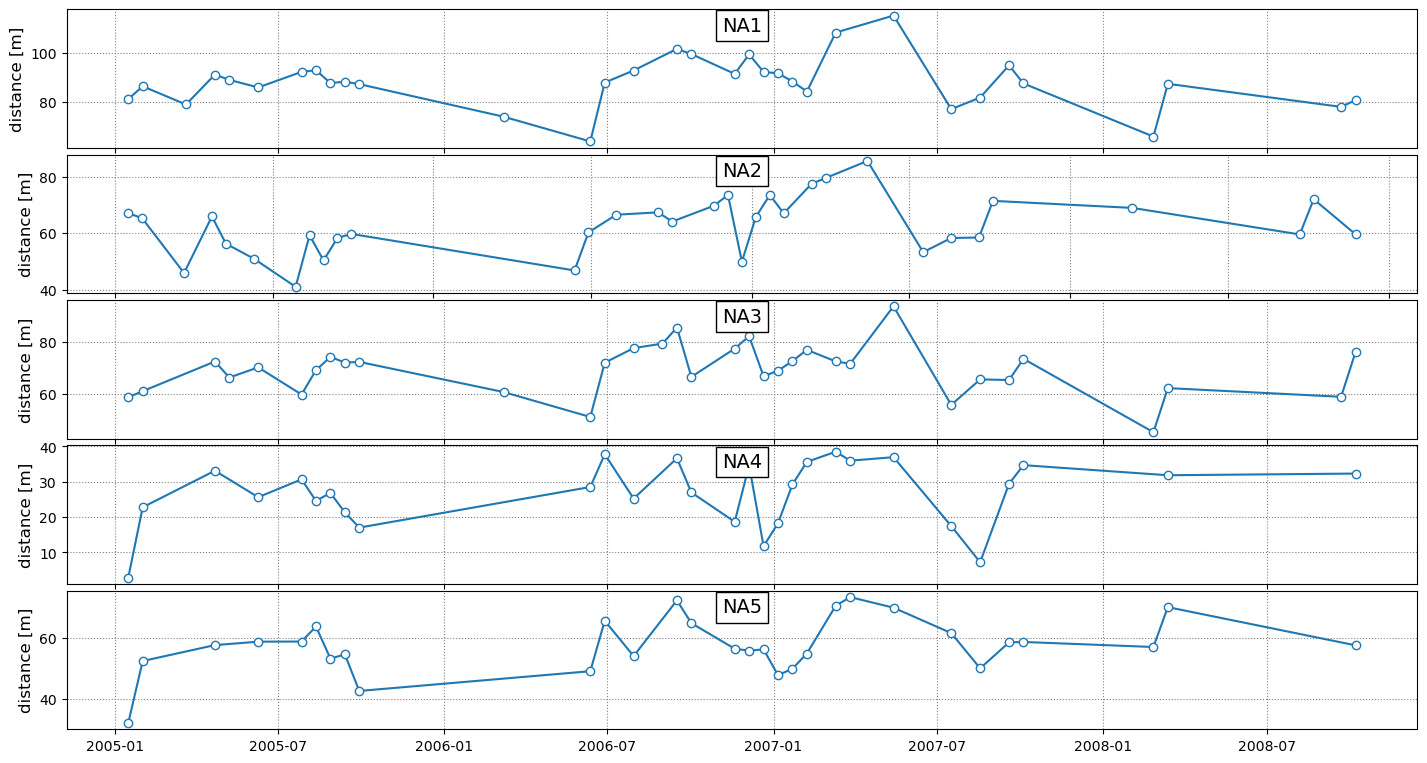

In [24]:
fig = plt.figure(figsize=[15,8], tight_layout=True)
gs = gridspec.GridSpec(len(cross_distance),1)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)
for i,key in enumerate(cross_distance.keys()):
    if np.all(np.isnan(cross_distance[key])):
        continue
    idx_nan = np.isnan(cross_distance[key])
    dates = [output['dates'][_] for _ in np.where(~idx_nan)[0]]
    chainage = cross_distance[key][~idx_nan]
    ax = fig.add_subplot(gs[i,0])
    ax.grid(linestyle=':', color='0.5')
    ax.plot(dates, chainage, '-o', ms=6, mfc='w')
    ax.set_ylabel('distance [m]', fontsize=12)
    ax.text(0.5,0.95, key, bbox=dict(boxstyle="square", ec='k',fc='w'), ha='center',
            va='top', transform=ax.transAxes, fontsize=14)
fig.savefig(os.path.join(filepath,'%s_timeseries_raw.jpg'%sitename),dpi=200)

In [25]:
# save a .csv file for Excel users
out_dict = dict([])
out_dict['dates'] = output['dates']
for key in transects.keys():
    out_dict[key] = cross_distance[key]
df = pd.DataFrame(out_dict)
fn = os.path.join(filepath,'%s_time_series_raw.csv'%sitename)
df.to_csv(fn, sep=',')
print('Time-series of the shoreline change along the transects saved as:\n%s'%fn)

Time-series of the shoreline change along the transects saved as:
C:\Users\ADMIN\Downloads\CoastSat-SuperResolution-new\CoastSat-SuperResolution-main\data\zhao\zhao_time_series_raw.csv


## Tidal correction
Use the [FES2022](https://www.aviso.altimetry.fr/en/data/products/auxiliary-products/global-tide-fes/release-fes22.html) global tide model to predict tide levels at the time of image acquisition. To setup FES2022 on your machine follow the instructions in [this document](https://github.com/kvos/CoastSat/blob/master/doc/FES2022_setup.md). **IMPORTANT**: if you don't have enough RAM to load the global model, there is a script to clip the netcdf files by latitude and reduce the needed RAM [clip_tide_netcdf_by_latitude.py](./examples/tide_model_clipping/clip_tide_netcdf_by_latitude.py), make sure you run this script before proceeding.

In [26]:
# import coastsat.slope module
from coastsat import SDS_slope
# load pyfes and the global tide model
import pyfes

In [27]:
# get polygon centroid, coordinates to get tides from
centroid = np.mean(polygon[0], axis=0)
print(centroid)
# if longitude is negative add 180 (longitudes are from 0 to 360 in fes)
if centroid[0] < 0: centroid[0] += 360

[151.3023463 -33.7239154]


Extracting closest points: 100%Number of satellite images used for tidal correction: 38
Number of interpolated tide values: 38
Time range: 2005-01-15 23:29:50+00:00 to 2008-11-23 23:27:17+00:00
Mean absolute difference compared with nearest-neighbour tide: 0.0219 m
Maximum absolute difference compared with nearest-neighbour tide: 0.0669 m
Maximum shoreline difference for slope=0.1: 0.669 m


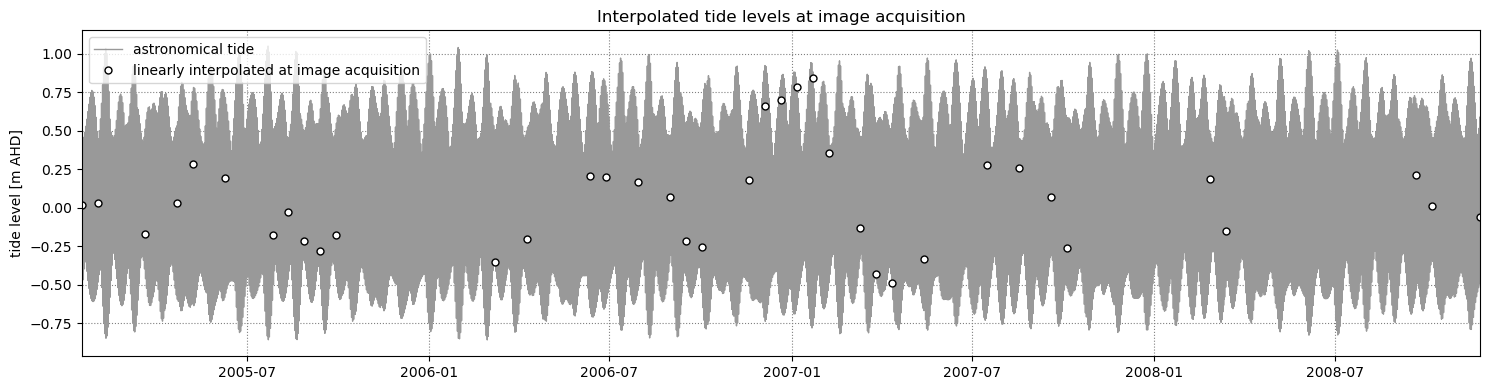

In [28]:
import os
from datetime import timezone, timedelta

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

filepath = os.path.join(os.getcwd(), "examples", "fes19792026.csv")

tide_data = pd.read_csv(filepath)

time_column = "Date and time (dd/mm/yyyy HH:MM AEST)"
tide_column = "Elevation (m, FES2022 datum)"

dates_local = pd.to_datetime(tide_data[time_column], dayfirst=True, errors="coerce")
tides_all = pd.to_numeric(tide_data[tide_column], errors="coerce")

valid = dates_local.notna() & tides_all.notna()

dates_local = dates_local.loc[valid].reset_index(drop=True)
tides_ts = tides_all.loc[valid].to_numpy(dtype=float)

aest_fixed = timezone(timedelta(hours=10))

dates_ts_index = pd.DatetimeIndex(dates_local.dt.tz_localize(aest_fixed)).tz_convert("UTC")

order = np.argsort(dates_ts_index.asi8)

dates_ts_index = dates_ts_index[order]
tides_ts = tides_ts[order]

unique_time, unique_idx = np.unique(dates_ts_index.asi8, return_index=True)

dates_ts_index = dates_ts_index[unique_idx]
tides_ts = tides_ts[unique_idx]

dates_ts = dates_ts_index.to_pydatetime().tolist()

output_dates_utc = pd.DatetimeIndex(pd.to_datetime(output["dates"], utc=True))

idx = np.asarray(
    (output_dates_utc >= dates_ts_index[0]) &
    (output_dates_utc <= dates_ts_index[-1])
)

dates_sat_index = output_dates_utc[idx]
dates_sat = dates_sat_index.to_pydatetime().tolist()

if len(dates_sat) == 0:
    raise ValueError("No satellite images fall within the tide data time range.")

# Check that cross_distance still corresponds to the original output
for key, values in cross_distance.items():
    if len(values) != len(output["dates"]):
        raise ValueError(
            f"{key}: cross_distance contains {len(values)} elements, "
            f"but output['dates'] contains {len(output['dates'])}. "
            "Please rerun the original cross_distance computation cell before this cell."
        )

cross_distance = {
    key: np.asarray(values)[idx]
    for key, values in cross_distance.items()
}

satnames_sat = np.asarray(output["satname"])[idx].tolist()

tide_time_numeric = dates_ts_index.asi8.astype(np.float64)
sat_time_numeric = dates_sat_index.asi8.astype(np.float64)

tides_sat = np.interp(sat_time_numeric, tide_time_numeric, tides_ts)

tides_sat_nearest = SDS_tools.get_closest_datapoint(
    dates_sat, dates_ts, tides_ts
)

difference = tides_sat - tides_sat_nearest

print("Number of satellite images used for tidal correction:", len(dates_sat))
print("Number of interpolated tide values:", len(tides_sat))
print("Time range:", dates_sat[0], "to", dates_sat[-1])

print(
    "Mean absolute difference compared with nearest-neighbour tide:",
    round(np.mean(np.abs(difference)), 4),
    "m"
)

print(
    "Maximum absolute difference compared with nearest-neighbour tide:",
    round(np.max(np.abs(difference)), 4),
    "m"
)

print(
    "Maximum shoreline difference for slope=0.1:",
    round(np.max(np.abs(difference)) / 0.1, 3),
    "m"
)

fig, ax = plt.subplots(1, 1, figsize=(15, 4), tight_layout=True)

ax.grid(which="major", linestyle=":", color="0.5")

ax.plot(
    dates_ts,
    tides_ts,
    "-",
    color="0.6",
    linewidth=1,
    label="astronomical tide"
)

ax.plot(
    dates_sat,
    tides_sat,
    "o",
    color="k",
    ms=5,
    mfc="w",
    label="linearly interpolated at image acquisition"
)

ax.set(
    ylabel="tide level [m AHD]",
    xlim=[dates_sat[0], dates_sat[-1]],
    title="Interpolated tide levels at image acquisition"
)

ax.legend()

fig.savefig(
    os.path.join(os.getcwd(), "examples", f"{sitename}_tide_timeseries_interpolated.jpg"),
    dpi=200
)

plt.show()

In [29]:
print(len(dates_sat), len(tides_sat))
for key in cross_distance:
    print(key, len(cross_distance[key]))

38 38
NA1 38
NA2 38
NA3 38
NA4 38
NA5 38


Tidally-corrected time-series of shoreline change saved as:
C:\Users\ADMIN\Downloads\CoastSat-SuperResolution-new\CoastSat-SuperResolution-main\examples\zhao_time_series_tidally_corrected.csv


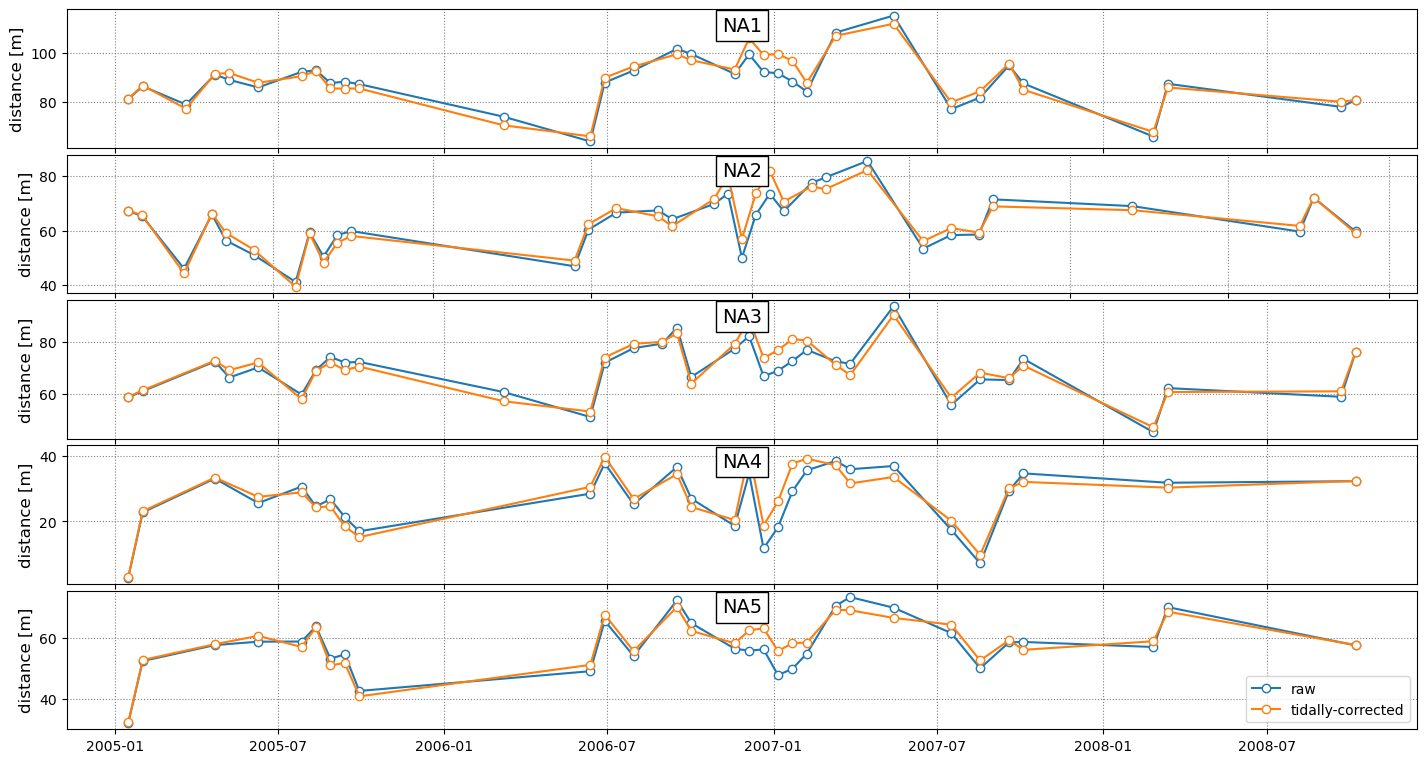

In [30]:
# tidal correction along each transect
reference_elevation = 0
beach_slope = 0.1

cross_distance_tidally_corrected = {}

for key in cross_distance.keys():
    correction = (tides_sat - reference_elevation) / beach_slope
    cross_distance_tidally_corrected[key] = cross_distance[key] + correction

# store the tidally-corrected time-series in a .csv file
out_dict = {'dates': dates_sat}

for key in cross_distance_tidally_corrected.keys():
    out_dict[key] = cross_distance_tidally_corrected[key]

df = pd.DataFrame(out_dict)

fn = os.path.join(
    os.getcwd(),
    'examples',
    f'{sitename}_time_series_tidally_corrected.csv'
)

df.to_csv(fn, index=False)

print('Tidally-corrected time-series of shoreline change saved as:\n%s' % fn)

# plot raw and tidally-corrected time-series
fig = plt.figure(figsize=[15, 8], tight_layout=True)

gs = gridspec.GridSpec(len(cross_distance), 1)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)

for i, key in enumerate(cross_distance.keys()):

    if np.all(np.isnan(cross_distance[key])):
        continue

    idx_nan = np.isnan(cross_distance[key])

    dates_plot = [
        dates_sat[j]
        for j in np.where(~idx_nan)[0]
    ]

    chainage = cross_distance[key][~idx_nan]
    chainage_corrected = cross_distance_tidally_corrected[key][~idx_nan]

    ax = fig.add_subplot(gs[i, 0])

    ax.grid(linestyle=':', color='0.5')

    ax.plot(
        dates_plot,
        chainage,
        '-o',
        ms=6,
        mfc='w',
        label='raw'
    )

    ax.plot(
        dates_plot,
        chainage_corrected,
        '-o',
        ms=6,
        mfc='w',
        label='tidally-corrected'
    )

    ax.set_ylabel('distance [m]', fontsize=12)

    ax.text(
        0.5,
        0.95,
        key,
        bbox=dict(boxstyle='square', ec='k', fc='w'),
        ha='center',
        va='top',
        transform=ax.transAxes,
        fontsize=14
    )

ax.legend()

fig.savefig(
    os.path.join(
        os.getcwd(),
        'examples',
        f'{sitename}_timeseries_corrected.jpg'
    ),
    dpi=200
)

## Time-series post-processing

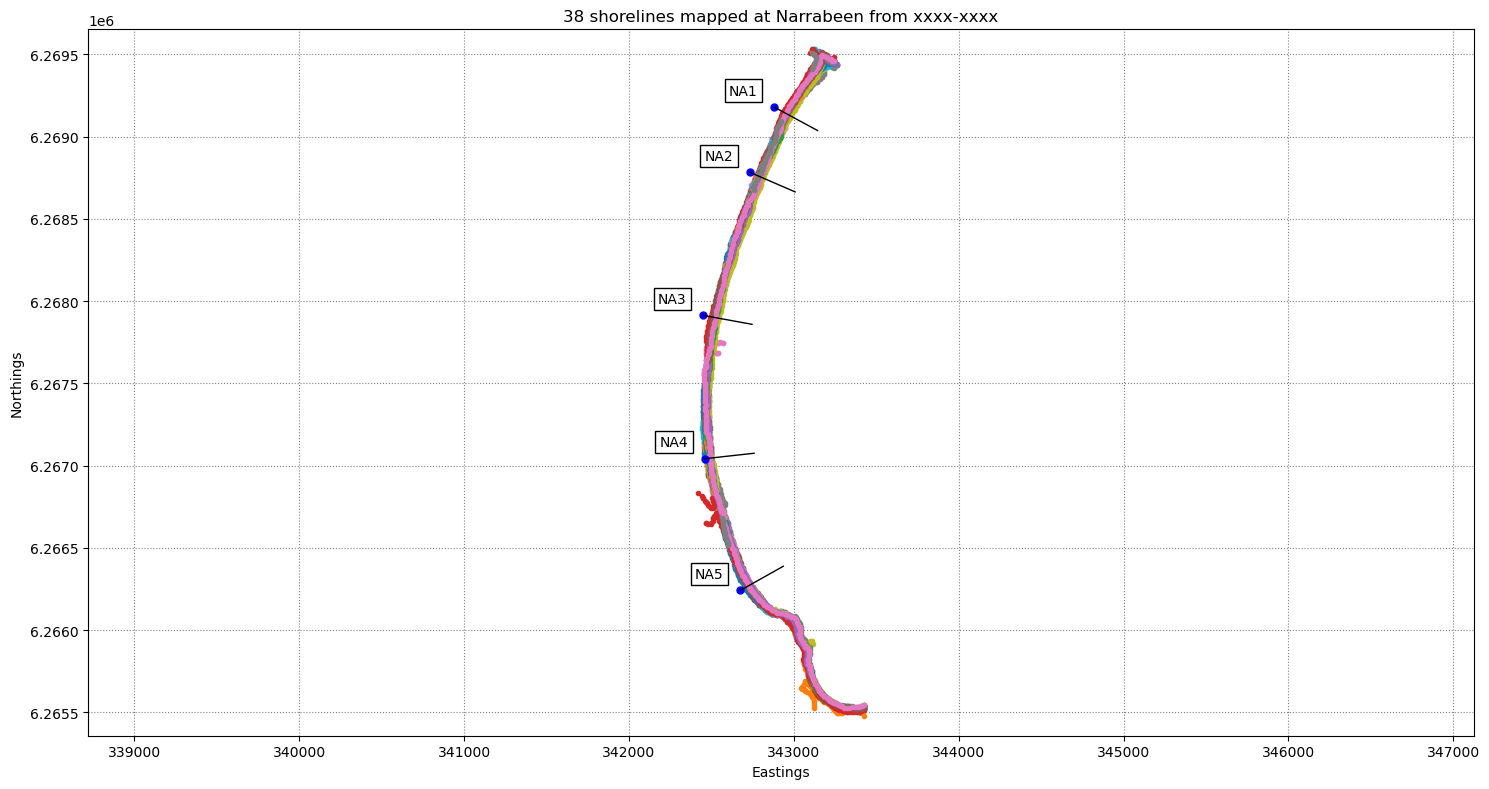

In [31]:
# load mapped shorelines from 1984
filename_output = os.path.join(
    os.getcwd(),
    'data',
    'zhao',
    'zhao_output.pkl'
)

with open(filename_output, 'rb') as f:
    output = pickle.load(f)

# plot the mapped shorelines
fig = plt.figure(figsize=[15,8], tight_layout=True)
plt.axis('equal')
plt.xlabel('Eastings')
plt.ylabel('Northings')
plt.grid(linestyle=':', color='0.5')
plt.title('%d shorelines mapped at Narrabeen from xxxx-xxxx'%len(output['shorelines']))
for i in range(len(output['shorelines'])):
    sl = output['shorelines'][i]
    date = output['dates'][i]
    plt.plot(sl[:,0], sl[:,1], '.', label=date.strftime('%d-%m-%Y'))
for i,key in enumerate(list(transects.keys())):
    plt.plot(transects[key][0,0],transects[key][0,1], 'bo', ms=5)
    plt.plot(transects[key][:,0],transects[key][:,1],'k-',lw=1)
    plt.text(transects[key][0,0]-100, transects[key][0,1]+100, key,
             va='center', ha='right', bbox=dict(boxstyle="square", ec='k',fc='w'))

# load long time-series (1984-2021)
filename_ts = os.path.join(os.getcwd(),'examples','zhao_time_series_tidally_corrected.csv')
df = pd.read_csv(filename_ts, parse_dates=['dates'])
dates = [_.to_pydatetime() for _ in df['dates']]
cross_distance = dict([])
for key in transects.keys():
    cross_distance[key] = np.array(df[key])

## Validation against surveys

This section provides a validation of the satellite-derived shorelines at Narrabeen-Collaroy against the survey data, available at http://narrabeen.wrl.unsw.edu.au/download/narrabeen/.

First, you need to download the survey data from the website. Go to the website, click `Download data`, then create a new user and select `Narrabeen Profile Data` as shown below:

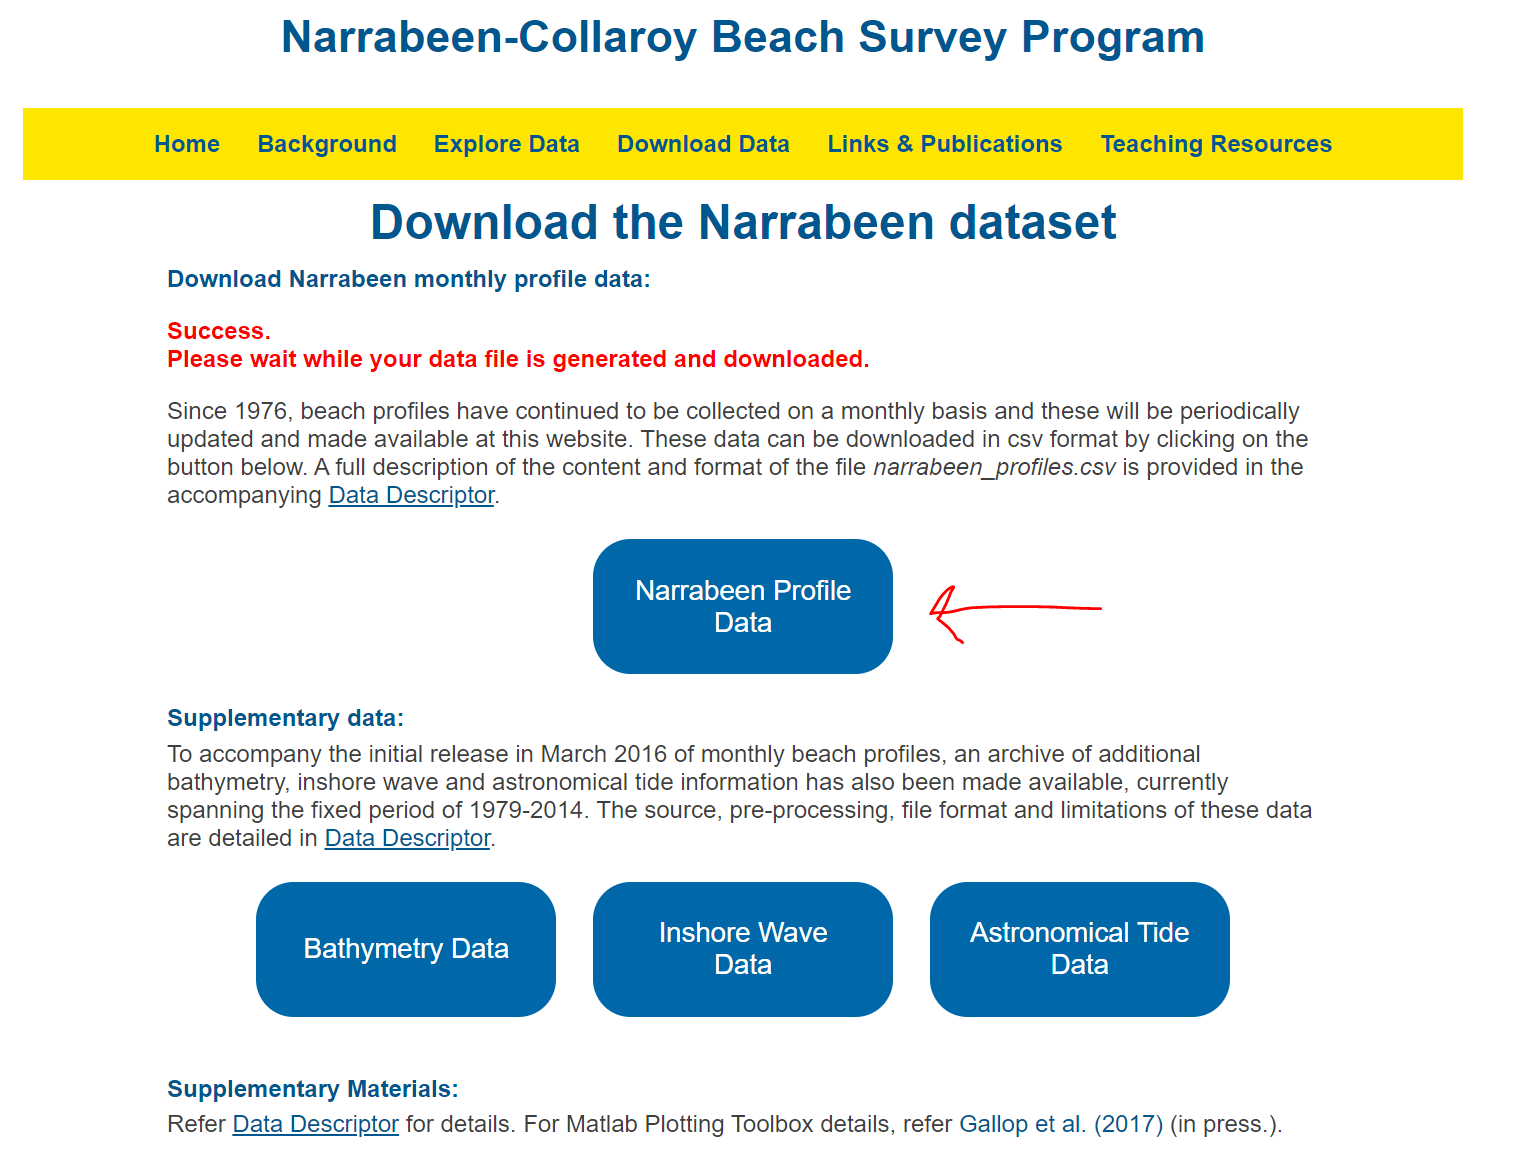

A csv file called `Narrabeen_profiles.csv` will be downloaded, copy it into the `./examples` folder. The code below is used to preprocess the data into time-series of shoreline change at a user-define contour level.

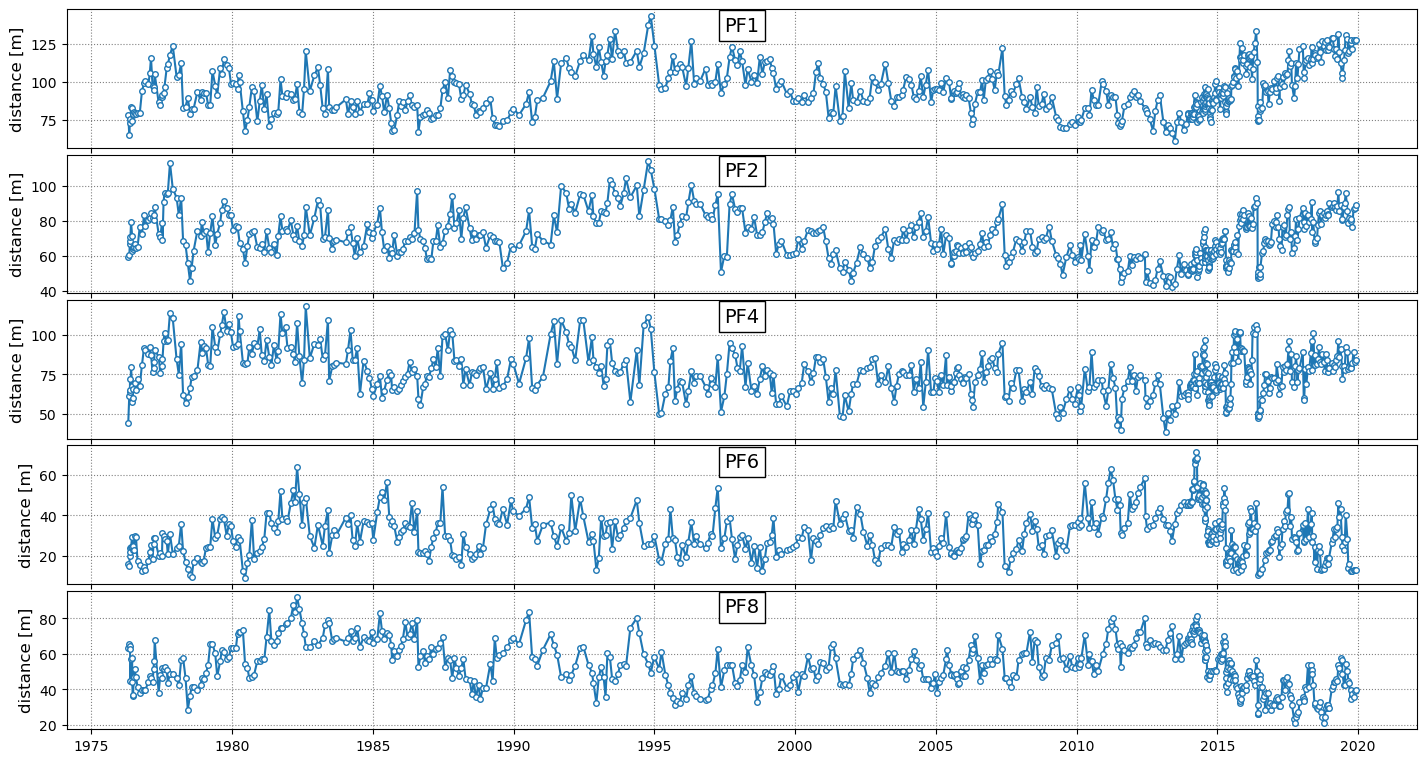

In [32]:
from scipy import interpolate
from scipy import stats
from datetime import timedelta
import pytz
# read the csv file
fp_datasets = os.path.join(os.getcwd(),'examples','Narrabeen_Profiles.csv')
df = pd.read_csv(fp_datasets)
pf_names = list(np.unique(df['Profile ID']))

# select contour level
contour_level = 0.7

# initialise topo_profiles structure
topo_profiles = {}

for i in range(len(pf_names)):

    # select one profile
    df_pf = df.loc[df['Profile ID'] == pf_names[i]].copy()

    # convert dates to datetime
    df_pf['Date'] = pd.to_datetime(
        df_pf['Date'],
        errors='coerce'
    )

    # remove invalid dates
    df_pf = df_pf.dropna(subset=['Date'])

    # sort by time
    df_pf = df_pf.sort_values('Date')

    # get unique dates in chronological order
    dates_unique = df_pf['Date'].drop_duplicates().sort_values()

    # initialise output for this profile
    topo_profiles[pf_names[i]] = {
        'dates': [],
        'chainages': []
    }

    for date in dates_unique:

        # extract chainage and elevation for this profile and date
        df_date = df_pf.loc[df_pf['Date'] == date]

        chainages = np.array(df_date['Chainage'])
        elevations = np.array(df_date['Elevation'])

        if len(chainages) == 0:
            continue

        # sort by elevation before interpolation
        idx_sort = np.argsort(elevations)
        elevations = elevations[idx_sort]
        chainages = chainages[idx_sort]

        # remove duplicated elevation values
        elevations_unique, idx_unique = np.unique(
            elevations,
            return_index=True
        )
        chainages_unique = chainages[idx_unique]

        if len(elevations_unique) < 2:
            continue

        # interpolate chainage at selected contour level
        f = interpolate.interp1d(
            elevations_unique,
            chainages_unique,
            bounds_error=False,
            fill_value=np.nan
        )

        chainage_contour_level = float(f(contour_level))

        if np.isnan(chainage_contour_level):
            continue

        # convert date to UTC
        date_utc = date.to_pydatetime()

        if date_utc.tzinfo is None:
            date_utc = pytz.utc.localize(date_utc)
        else:
            date_utc = date_utc.astimezone(pytz.utc)

        topo_profiles[pf_names[i]]['dates'].append(date_utc)
        topo_profiles[pf_names[i]]['chainages'].append(
            chainage_contour_level
        )

# plot time-series
fig = plt.figure(figsize=[15,8], tight_layout=True)
gs = gridspec.GridSpec(len(topo_profiles),1)
gs.update(left=0.05, right=0.95, bottom=0.05, top=0.95, hspace=0.05)
for i,key in enumerate(topo_profiles.keys()):
    ax = fig.add_subplot(gs[i,0])
    ax.grid(linestyle=':', color='0.5')
    ax.plot(topo_profiles[key]['dates'], topo_profiles[key]['chainages'], '-o', ms=4, mfc='w')
    ax.set_ylabel('distance [m]', fontsize=12)
    ax.text(0.5,0.95, key, bbox=dict(boxstyle="square", ec='k',fc='w'), ha='center',
            va='top', transform=ax.transAxes, fontsize=14)  
# save a .pkl file
with open(os.path.join(os.getcwd(), 'examples', 'Narrabeen_ts_07m.pkl'), 'wb') as f:
    pickle.dump(topo_profiles, f)

In [33]:
filename_ts = os.path.join(os.getcwd(), 'examples', f'{sitename}_time_series_tidally_corrected.csv')
df = pd.read_csv(filename_ts, parse_dates=['dates'])

dates = df['dates'].dt.to_pydatetime().tolist()
cross_distance = {}

for key in transects.keys():
    cross_distance[key] = df[key].to_numpy()

print(cross_distance.keys())

dict_keys(['NA1', 'NA2', 'NA3', 'NA4', 'NA5'])


In [34]:
old_keys = list(cross_distance.keys())
gt_keys = list(gt.keys())

cross_distance = {
    gt_keys[i]: cross_distance[old_keys[i]]
    for i in range(len(old_keys))
}

print(cross_distance.keys())

NameError: name 'gt' is not defined

cross_distance: dict_keys(['PF1', 'PF2', 'PF4', 'PF6', 'PF8'])
Number of transects: 5


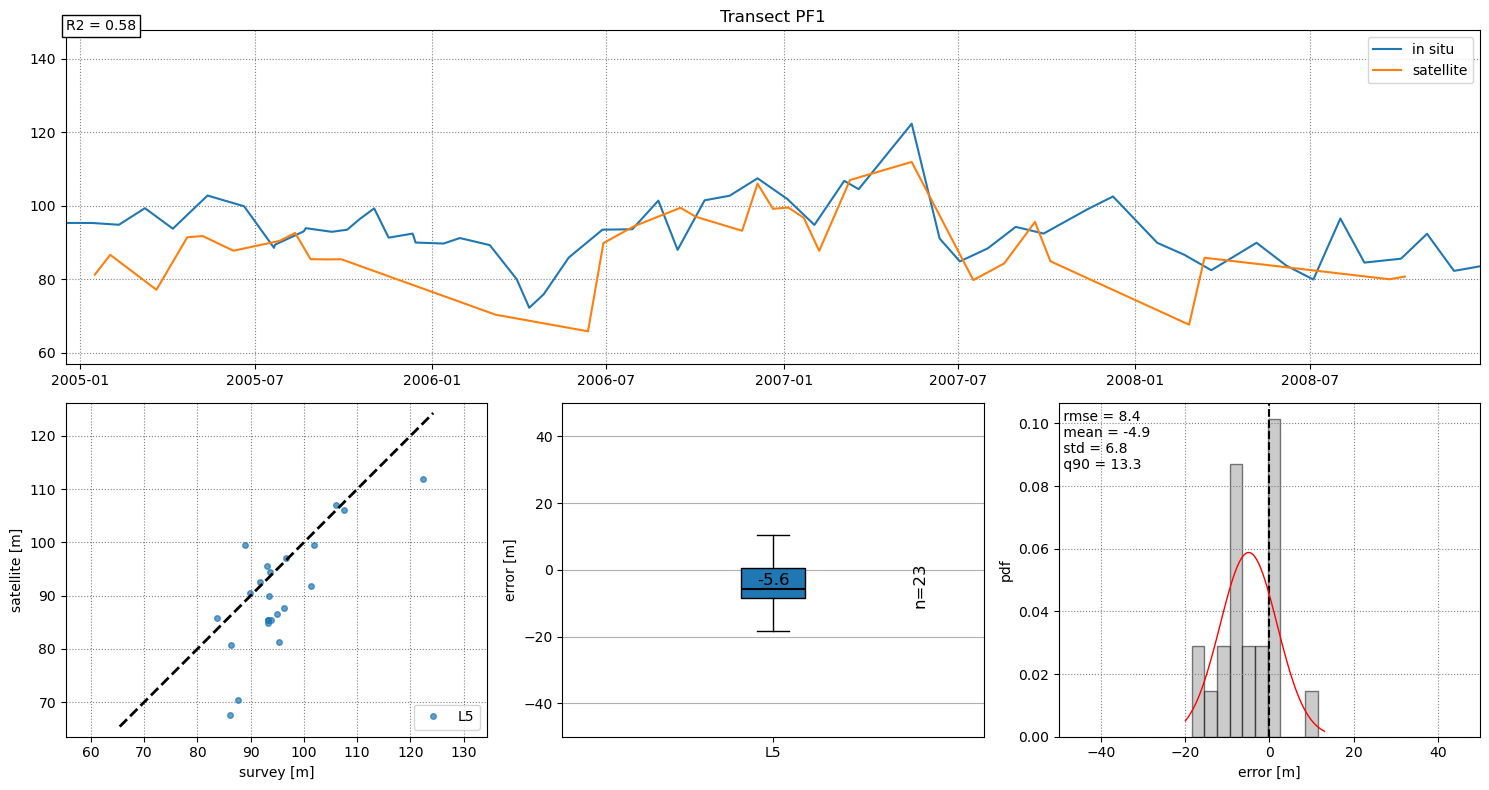

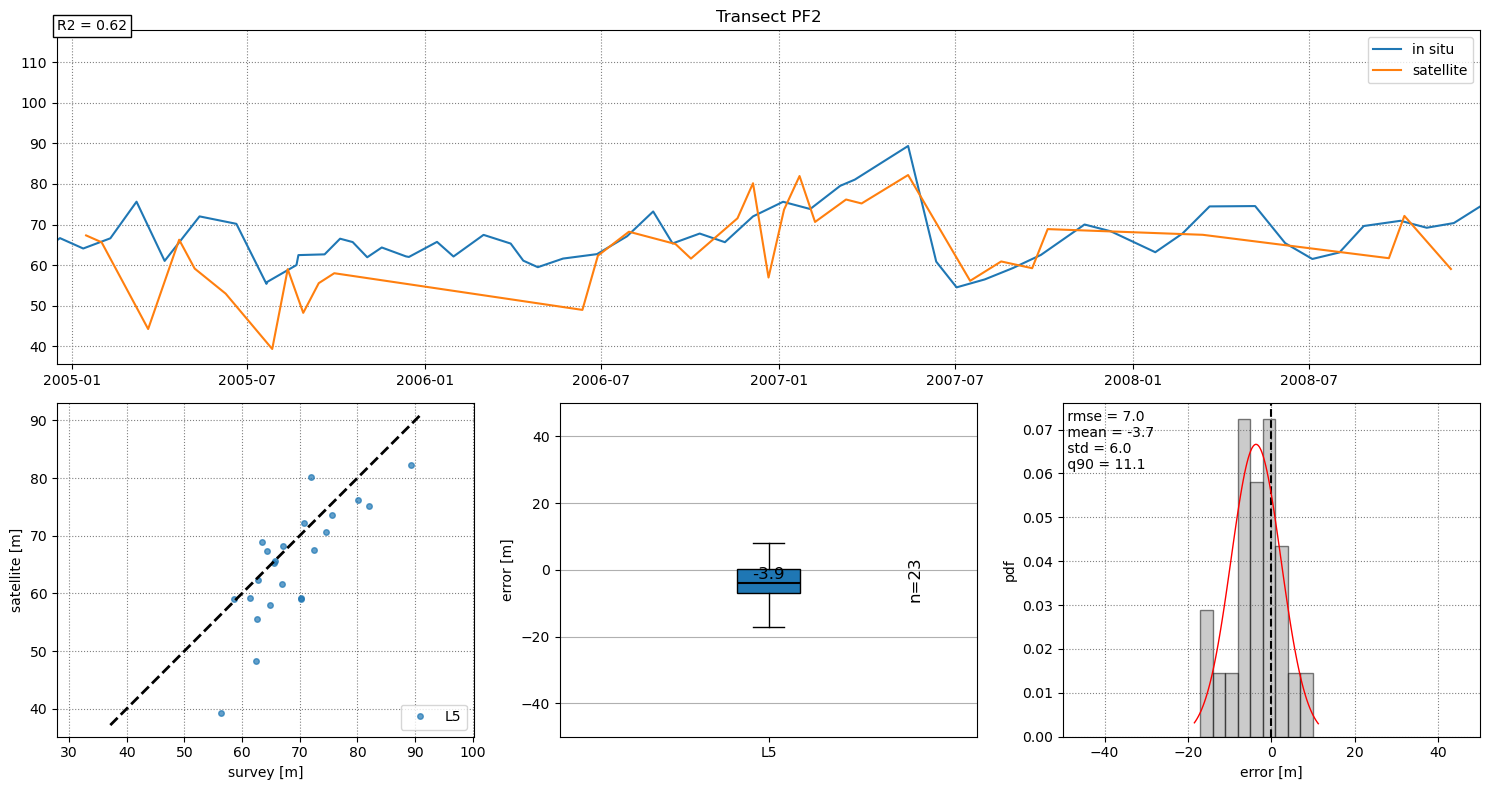

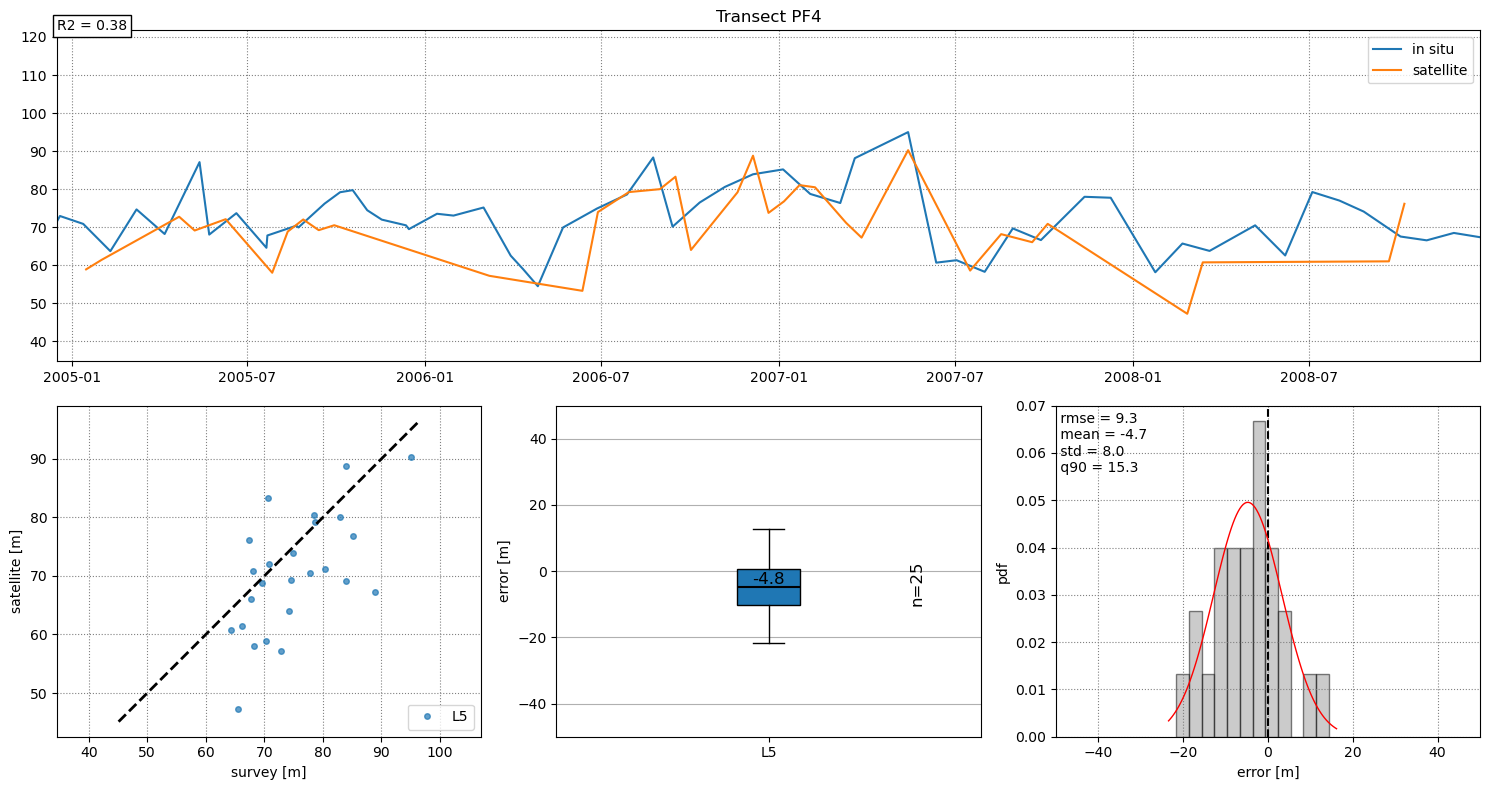

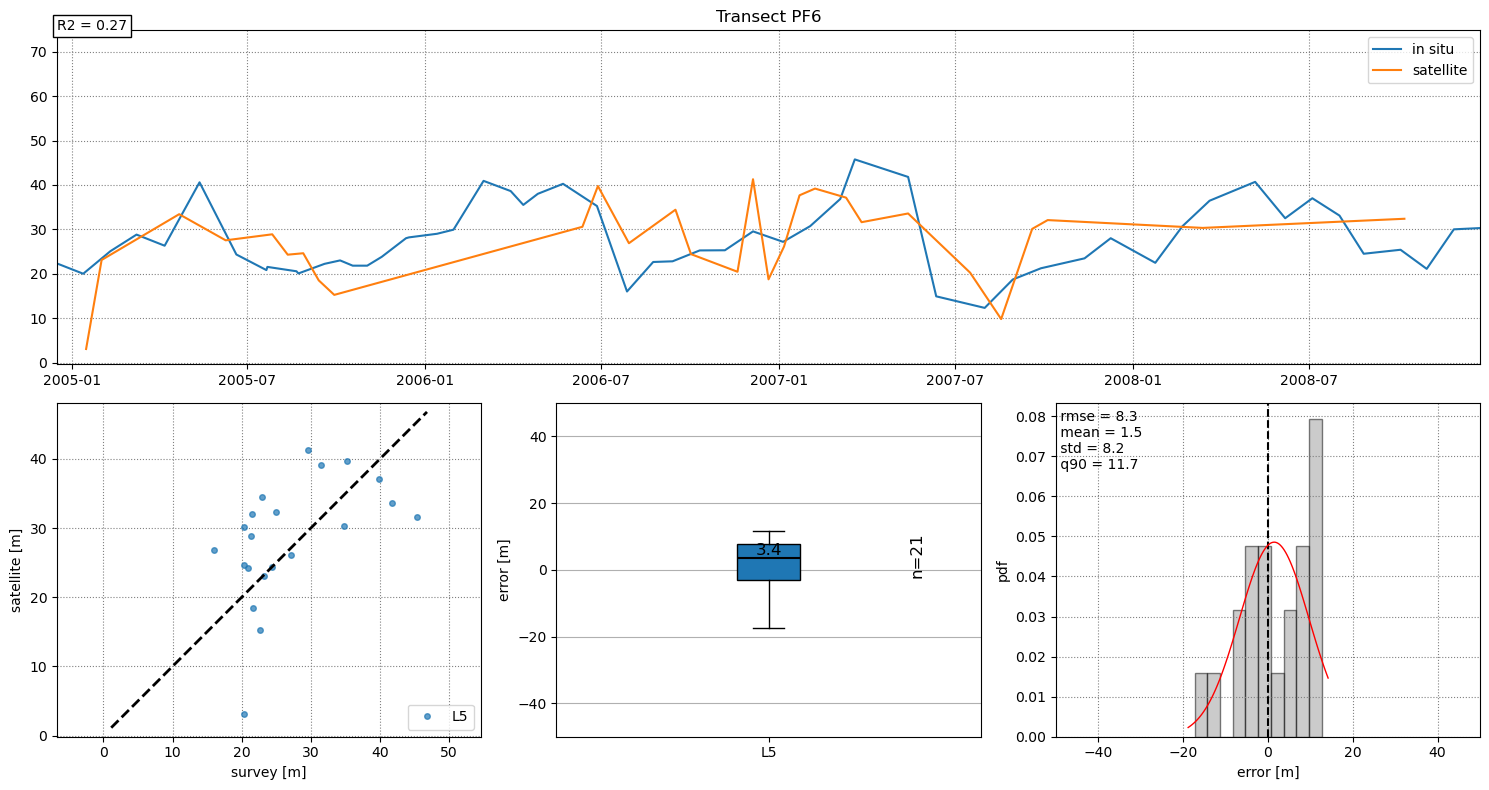

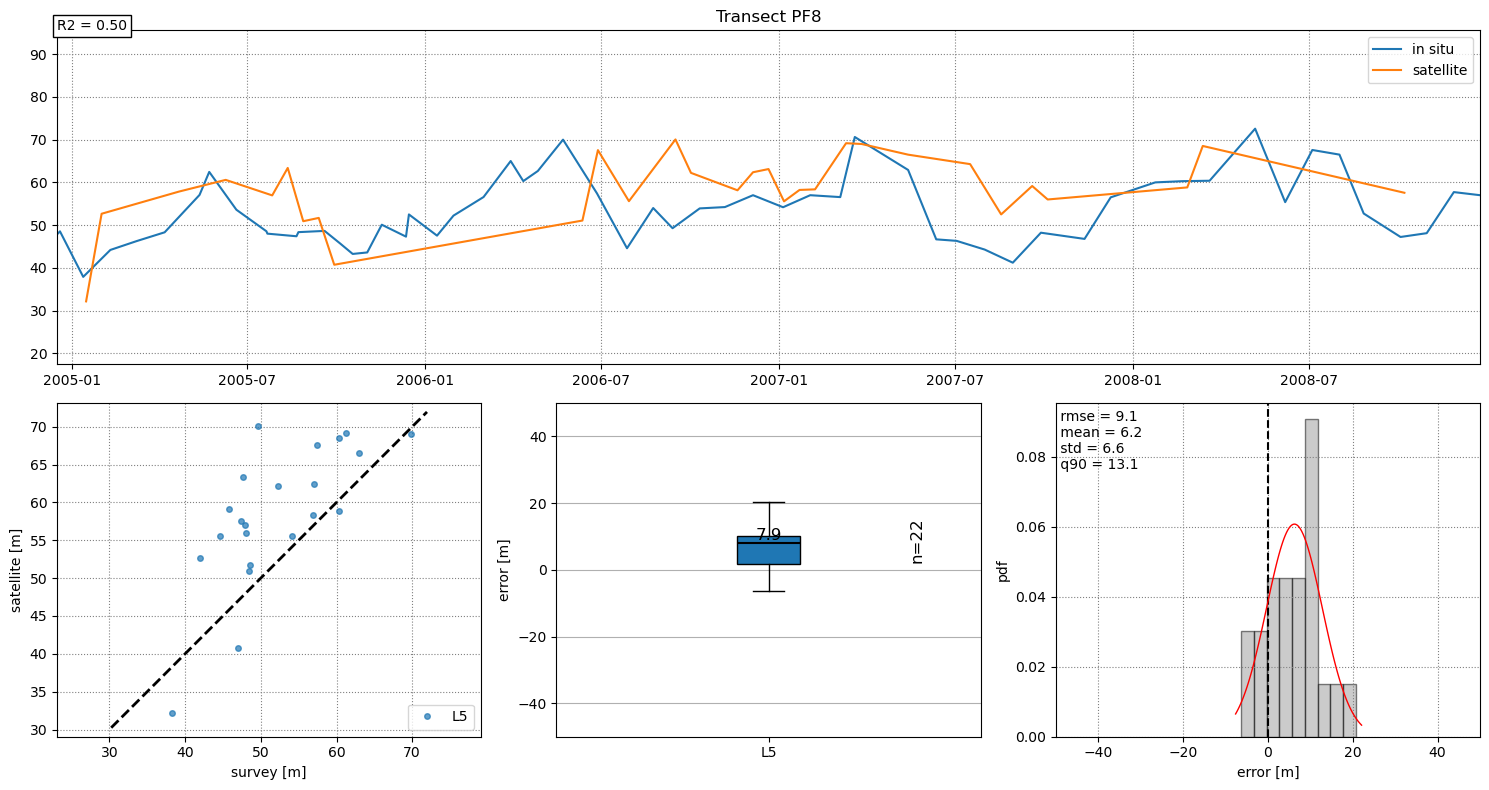

In [35]:
# Display figures directly below the cell instead of opening separate Figure windows
%matplotlib inline

import os
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datetime import timedelta
from scipy import interpolate, stats
from matplotlib import gridspec
from IPython.display import display

# Close all previously opened Figure windows
plt.close("all")

# ============================================================
# 1. LOAD SURVEY DATA
# ============================================================

with open(os.path.join(os.getcwd(), "examples", "Narrabeen_ts_07m.pkl"), "rb") as f:
    gt = pickle.load(f)

# Rename transects to match the survey data
# Only perform this step if the current names do not already match
if set(cross_distance.keys()) != set(gt.keys()):

    old_keys = list(cross_distance.keys())
    gt_keys = list(gt.keys())

    cross_distance = {
        gt_keys[i]: cross_distance[old_keys[i]]
        for i in range(min(len(old_keys), len(gt_keys)))
    }

# ============================================================
# 2. PARAMETERS
# ============================================================

sett = {
    "min_days": 3,
    "max_days": 10,
    "binwidth": 3,
    "lims": [-50, 50]
}

# ============================================================
# 3. INITIALISE VARIABLES
# ============================================================

chain_sat_all = []
chain_sur_all = []
satnames_all = []

# Store results for the final table
rows = []

print("cross_distance:", cross_distance.keys())
print("Number of transects:", len(cross_distance))

# ============================================================
# 4. LOOP THROUGH THE FIVE TRANSECTS
# ============================================================

for key in cross_distance.keys():

    # --------------------------------------------------------
    # Remove NaNs
    # --------------------------------------------------------

    chainage = np.asarray(cross_distance[key], dtype=float)

    idx_nan = np.isnan(chainage)
    valid_indices = np.where(~idx_nan)[0]

    dates_nonans = [dates_sat[k] for k in valid_indices]
    satnames_nonans = [satnames_sat[k] for k in valid_indices]

    chain_nonans = chainage[~idx_nan]

    chain_sat_dm = chain_nonans
    chain_sur_dm = gt[key]["chainages"]


    # --------------------------------------------------------
    # Create figure
    # --------------------------------------------------------

    fig = plt.figure(figsize=(15, 8), tight_layout=True)

    gs = gridspec.GridSpec(2, 3)

    ax0 = fig.add_subplot(gs[0, :])

    ax0.grid(which="major", linestyle=":", color="0.5")

    ax0.plot(
        gt[key]["dates"],
        chain_sur_dm,
        "-",
        mfc="w",
        ms=5,
        label="in situ"
    )

    ax0.plot(
        dates_nonans,
        chain_sat_dm,
        "-",
        mfc="w",
        ms=5,
        label="satellite"
    )

    ax0.set(
        title="Transect " + key,
        xlim=[
            output["dates"][0] - timedelta(days=30),
            output["dates"][-1] + timedelta(days=30)
        ]
    )

    ax0.legend()

    # --------------------------------------------------------
    # Interpolate survey data around satellite dates
    # --------------------------------------------------------

    chain_int = np.full(len(dates_nonans), np.nan, dtype=float)

    for k, date in enumerate(dates_nonans):

        days_diff = np.array([
            (_ - date).days
            for _ in gt[key]["dates"]
        ])

        # No survey data within 10 days
        if np.min(np.abs(days_diff)) > sett["max_days"]:

            chain_int[k] = np.nan

        else:

            # Survey data available within less than 3 days
            if np.min(np.abs(days_diff)) < sett["min_days"]:

                idx_closest = np.where(
                    np.abs(days_diff) == np.min(np.abs(days_diff))
                )[0][0]

                chain_int[k] = float(gt[key]["chainages"][idx_closest])

            # Interpolate when the time difference is between 3 and 10 days
            else:

                # No survey data after the satellite acquisition date
                if np.sum(days_diff > 0) == 0:
                    continue

                idx_after = np.where(days_diff > 0)[0][0]
                idx_before = idx_after - 1

                # Avoid incorrectly using the last element when no previous point exists
                if idx_before < 0:
                    continue

                x_interp = [
                    gt[key]["dates"][idx_before].toordinal(),
                    gt[key]["dates"][idx_after].toordinal()
                ]

                y_interp = [
                    gt[key]["chainages"][idx_before],
                    gt[key]["chainages"][idx_after]
                ]

                interpolation_function = interpolate.interp1d(
                    x_interp,
                    y_interp,
                    bounds_error=True
                )

                chain_int[k] = float(
                    interpolation_function(date.toordinal())
                )


    # --------------------------------------------------------
    # Remove unmatched values
    # --------------------------------------------------------

    idx_valid = np.isfinite(chain_int)

    chain_sat = chain_nonans[idx_valid]
    chain_sur = chain_int[idx_valid]

    matched_indices = np.where(idx_valid)[0]

    dates_matched = [dates_nonans[k] for k in matched_indices]
    satnames = [satnames_nonans[k] for k in matched_indices]

    satnames_array = np.asarray(satnames)


    # --------------------------------------------------------
    # Combine all transects
    # --------------------------------------------------------

    chain_sat_all = np.append(chain_sat_all, chain_sat)
    chain_sur_all = np.append(chain_sur_all, chain_sur)

    satnames_all = satnames_all + satnames


    # --------------------------------------------------------
    # Error statistics for the current transect
    # --------------------------------------------------------

    slope, intercept, rvalue, pvalue, std_err = stats.linregress(
        chain_sur,
        chain_sat
    )

    R2 = rvalue**2

    chain_error = chain_sat - chain_sur

    rmse = np.sqrt(np.mean(chain_error**2))
    mean_error = np.mean(chain_error)
    std_error = np.std(chain_error)
    q90 = np.percentile(np.abs(chain_error), 90)


    # Display R²
    ax0.text(
        0,
        1,
        "R2 = %.2f" % R2,
        bbox=dict(boxstyle="square", facecolor="w", alpha=1),
        transform=ax0.transAxes
    )


    # --------------------------------------------------------
    # Save statistics in memory for the final table
    # --------------------------------------------------------

    for sat in np.unique(satnames_array):

        idx_sat = satnames_array == sat

        error_sat = chain_error[idx_sat]
        satellite_values = chain_sat[idx_sat]
        survey_values = chain_sur[idx_sat]

        valid_sat = (
            np.isfinite(error_sat) &
            np.isfinite(satellite_values) &
            np.isfinite(survey_values)
        )

        error_sat = error_sat[valid_sat]
        satellite_values = satellite_values[valid_sat]
        survey_values = survey_values[valid_sat]

        if len(error_sat) == 0:
            continue

        # R² for each individual satellite
        if (
            len(error_sat) >= 2 and
            np.std(satellite_values) > 0 and
            np.std(survey_values) > 0
        ):

            r_sat = stats.linregress(
                survey_values,
                satellite_values
            ).rvalue

            r2_sat = r_sat**2

        else:

            r2_sat = np.nan

        rows.append({
            "Transect": key,
            "Satellite": sat,
            "n": len(error_sat),
            "R2": r2_sat,
            "Mean/Bias (m)": np.mean(error_sat),
            "Median (m)": np.median(error_sat),
            "MAE (m)": np.mean(np.abs(error_sat)),
            "RMSE (m)": np.sqrt(np.mean(error_sat**2)),
            "STD (m)": np.std(error_sat),
            "Q90 abs (m)": np.percentile(np.abs(error_sat), 90)
        })


    # --------------------------------------------------------
    # 1:1 plot
    # --------------------------------------------------------

    ax1 = fig.add_subplot(gs[1, 0])

    ax1.axis("equal")
    ax1.grid(which="major", linestyle=":", color="0.5")

    unique_sats = list(np.unique(satnames_array))

    for k, sat in enumerate(unique_sats):

        idx = np.where(satnames_array == sat)[0]

        ax1.plot(
            chain_sur[idx],
            chain_sat[idx],
            "o",
            ms=4,
            mfc="C" + str(k),
            mec="C" + str(k),
            alpha=0.7,
            label=sat
        )

    ax1.legend(loc=4)

    plot_min = min(ax1.get_xlim()[0], ax1.get_ylim()[0])
    plot_max = max(ax1.get_xlim()[1], ax1.get_ylim()[1])

    ax1.plot(
        [plot_min, plot_max],
        [plot_min, plot_max],
        "k--",
        lw=2
    )

    ax1.set(
        xlabel="survey [m]",
        ylabel="satellite [m]"
    )


    # --------------------------------------------------------
    # Boxplot
    # --------------------------------------------------------

    ax2 = fig.add_subplot(gs[1, 1])

    data = []
    median_data = []
    n_data = []

    ax2.yaxis.grid()

    for sat in unique_sats:

        idx = np.where(satnames_array == sat)[0]

        data.append(chain_error[idx])
        median_data.append(np.median(chain_error[idx]))
        n_data.append(len(chain_error[idx]))

    bp = ax2.boxplot(
        data,
        0,
        "k.",
        labels=unique_sats,
        patch_artist=True
    )

    for median in bp["medians"]:
        median.set(color="k", linewidth=1.5)

    for j, boxes in enumerate(bp["boxes"]):

        boxes.set(facecolor="C" + str(j))

        ax2.text(
            j + 1,
            median_data[j] + 1,
            "%.1f" % median_data[j],
            horizontalalignment="center",
            fontsize=12
        )

        ax2.text(
            j + 1 + 0.35,
            median_data[j] + 1,
            "n=%d" % int(n_data[j]),
            ha="center",
            va="center",
            fontsize=12,
            rotation="vertical"
        )

    ax2.set(
        ylabel="error [m]",
        ylim=sett["lims"]
    )


    # --------------------------------------------------------
    # Histogram
    # --------------------------------------------------------

    ax3 = fig.add_subplot(gs[1, 2])

    ax3.grid(which="major", linestyle=":", color="0.5")

    ax3.axvline(
        x=0,
        ls="--",
        lw=1.5,
        color="k"
    )

    binwidth = sett["binwidth"]

    bins = np.arange(
        np.min(chain_error),
        np.max(chain_error) + binwidth,
        binwidth
    )

    ax3.hist(
        chain_error,
        bins=bins,
        density=True,
        color="0.6",
        edgecolor="k",
        alpha=0.5
    )

    mu_fit, std_fit = stats.norm.fit(chain_error)

    xlims = ax3.get_xlim()

    x_pdf = np.linspace(xlims[0], xlims[1], 100)
    p_pdf = stats.norm.pdf(x_pdf, mu_fit, std_fit)

    ax3.plot(
        x_pdf,
        p_pdf,
        "r-",
        linewidth=1
    )

    ax3.set(
        xlabel="error [m]",
        ylabel="pdf",
        xlim=sett["lims"]
    )

    str_stats = (
        " rmse = %.1f\n"
        " mean = %.1f\n"
        " std = %.1f\n"
        " q90 = %.1f"
        % (
            rmse,
            mean_error,
            std_error,
            q90
        )
    )

    ax3.text(
        0,
        0.98,
        str_stats,
        va="top",
        transform=ax3.transAxes
    )

    plt.show()



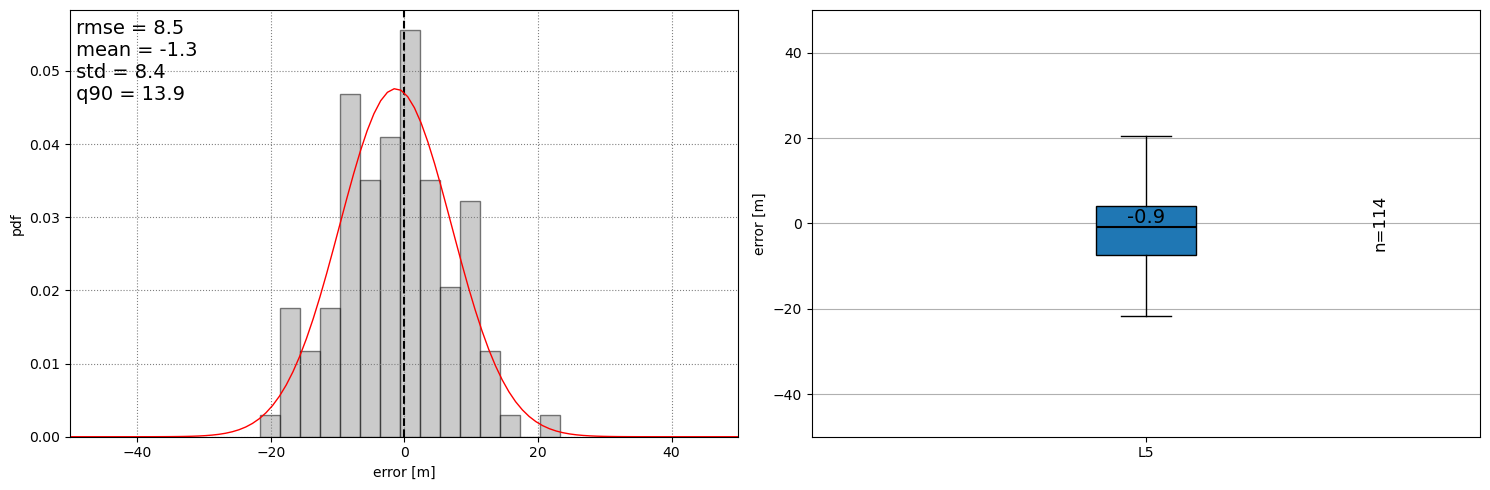

In [36]:
# calculate statistics for all transects together
chain_error = chain_sat_all - chain_sur_all        
slope, intercept, rvalue, pvalue, std_err = stats.linregress(chain_sur, chain_sat) 
R2 = rvalue**2
rmse = np.sqrt(np.mean((chain_error)**2))
mean = np.mean(chain_error)
std = np.std(chain_error)
q90 = np.percentile(np.abs(chain_error), 90)

fig,ax = plt.subplots(1,2,figsize=(15,5), tight_layout=True)
# histogram
ax[0].grid(which='major',linestyle=':',color='0.5')
ax[0].axvline(x=0, ls='--', lw=1.5, color='k')
binwidth=sett['binwidth']
bins = np.arange(min(chain_error), max(chain_error) + binwidth, binwidth)
density = ax[0].hist(chain_error, bins=bins, density=True, color='0.6', edgecolor='k', alpha=0.5)
mu, std = stats.norm.fit(chain_error)
pval = stats.normaltest(chain_error)[1]
xlims = ax3.get_xlim()
x = np.linspace(xlims[0], xlims[1], 100)
p = stats.norm.pdf(x, mu, std)
ax[0].plot(x, p, 'r-', linewidth=1)
ax[0].set(xlabel='error [m]', ylabel='pdf', xlim=sett['lims'])   
str_stats = ' rmse = %.1f\n mean = %.1f\n std = %.1f\n q90 = %.1f' % (rmse, mean, std, q90) 
ax[0].text(0, 0.98, str_stats,va='top', transform=ax[0].transAxes,fontsize=14)

# boxplot
data = []
median_data = []
n_data = []
ax[1].yaxis.grid()
for k,sat in enumerate(list(np.unique(satnames_all))):
    idx = np.where([_ == sat for _ in satnames_all])[0]
    data.append(chain_error[idx])
    median_data.append(np.median(chain_error[idx]))
    n_data.append(len(chain_error[idx]))
bp = ax[1].boxplot(data,0,'k.', labels=list(np.unique(satnames_all)), patch_artist=True)
for median in bp['medians']:
    median.set(color='k', linewidth=1.5)
for j,boxes in enumerate(bp['boxes']):
    boxes.set(facecolor='C'+str(j))
    ax[1].text(j+1,median_data[j]+1, '%.1f' % median_data[j], horizontalalignment='center', fontsize=14)
    ax[1].text(j+1+0.35,median_data[j]+1, ('n=%.d' % int(n_data[j])), ha='center', va='center', fontsize=12, rotation='vertical')
ax[1].set(ylabel='error [m]', ylim=sett['lims']);
fig.savefig(os.path.join(os.getcwd(),'examples','comparison_all_transects.jpg'), dpi=150)

In [44]:
import numpy as np
import pandas as pd

rows = []

for sat in np.unique(satnames_all):

    idx = np.asarray(satnames_all) == sat
    error = np.asarray(chain_error)[idx]
    error = error[np.isfinite(error)]

    rows.append({
        "Satellite": sat,
        "n": len(error),
        "Mean/Bias (m)": np.mean(error),
        "Median (m)": np.median(error),
        "MAE (m)": np.mean(np.abs(error)),
        "RMSE (m)": np.sqrt(np.mean(error**2)),
        "STD (m)": np.std(error),
        "Q90 abs (m)": np.percentile(np.abs(error), 90)
    })

metrics_sat = pd.DataFrame(rows).round(2)
display(metrics_sat)

,Satellite,n,Mean/Bias (m),Median (m),MAE (m),RMSE (m),STD (m),Q90 abs (m)
0,L5,71,1.23,2.42,8.51,10.32,10.25,16.3
